<a href="https://colab.research.google.com/github/govindkumarbuisnes-gif/usd-jpy/blob/main/Copy_of_untitled1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("fgh09101010/cypto-data")

100%|██████████| 390M/390M [00:11<00:00, 35.1MB/s]

Extracting files...


In [2]:
import os
import pandas as pd

# 2. List the files inside the downloaded folder to find the exact filename
files = os.listdir(path)
print("Files in dataset folder:", files)

# 3. Read a specific file (Assuming it contains a CSV file, e.g., 'crypto.csv')
# Change 'crypto.csv' to the actual name printed from step 2
file_path = os.path.join(path, files[0])  # Or os.path.join(path, "your_file.csv")

# Load it into Pandas
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())


Files in dataset folder: ['1_coinhistory.csv', '4_financial_data.csv', '7_daily_sentiment_only.csv', '5_economic_indicators.csv', '6_merged_crypto_news.csv', '8_llm_features_full.csv', '2_news_articles_all.csv', '3_bitcoin_metrics.csv']
                  date  open_price  high_price  low_price  close_price  \
0  2020-01-01 00:00:00     7195.24     7196.25    7183.14      7186.68   
1  2020-01-01 00:01:00     7187.67     7188.06    7182.20      7184.03   
2  2020-01-01 00:02:00     7184.41     7184.71    7180.26      7182.43   
3  2020-01-01 00:03:00     7183.83     7188.94    7182.49      7185.94   
4  2020-01-01 00:04:00     7185.54     7185.54    7178.64      7179.78   

      volume  
0  51.642812  
1   7.248148  
2  11.681677  
3  10.025391  
4  14.911105  


In [3]:
df

,date,open_price,high_price,low_price,close_price,volume
0,2020-01-01 00:00:00,7195.24,7196.25,7183.14,7186.68,51.642812
1,2020-01-01 00:01:00,7187.67,7188.06,7182.20,7184.03,7.248148
2,2020-01-01 00:02:00,7184.41,7184.71,7180.26,7182.43,11.681677
3,2020-01-01 00:03:00,7183.83,7188.94,7182.49,7185.94,10.025391
4,2020-01-01 00:04:00,7185.54,7185.54,7178.64,7179.78,14.911105
...,...,...,...,...,...,...
3121286,2025-12-05 23:12:00,89122.61,89122.62,89098.00,89098.00,1.190870
3121287,2025-12-05 23:13:00,89098.00,89098.01,89056.38,89056.38,2.067070
3121288,2025-12-05 23:14:00,89056.38,89123.46,89056.38,89123.46,6.077720
3121289,2025-12-05 23:15:00,89123.45,89150.00,89123.45,89149.99,1.783600


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3121291 entries, 0 to 3121290
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   date         object 
 1   open_price   float64
 2   high_price   float64
 3   low_price    float64
 4   close_price  float64
 5   volume       float64
dtypes: float64(5), object(1)
memory usage: 142.9+ MB


In [5]:
df.describe()

,open_price,high_price,low_price,close_price,volume
count,3.121291e+06,3.121291e+06,3.121291e+06,3.121291e+06,3.121291e+06
mean,4.675753e+04,4.677723e+04,4.673774e+04,4.675756e+04,5.177936e+01
std,3.132938e+04,3.133769e+04,3.132099e+04,3.132938e+04,9.760065e+01
min,3.810000e+03,3.900000e+03,3.782130e+03,3.810780e+03,0.000000e+00
25%,2.169979e+04,2.171006e+04,2.169019e+04,2.169977e+04,1.004461e+01
50%,3.931180e+04,3.934075e+04,3.928115e+04,3.931177e+04,2.257003e+01
75%,6.385837e+04,6.388193e+04,6.383340e+04,6.385843e+04,5.255471e+01
max,1.261145e+05,1.261996e+05,1.260719e+05,1.261145e+05,5.877775e+03


### Step 1: Preprocess Datetime and Prepare Features ($X$) and Target ($y$)
We will use `open_price`, `high_price`, `low_price`, and `volume` as features to predict the `close_price`.

In [6]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# The dataset has multiple files. We need to load '1_coinhistory.csv' which contains the price data.
coin_history_path = os.path.join(path, '1_coinhistory.csv')
df_prices = pd.read_csv(coin_history_path)

# Convert date column to datetime and sort by time
df_prices['date'] = pd.to_datetime(df_prices['date'])
df_prices = df_prices.sort_values('date').reset_index(drop=True)

# Define Features (X) and Target (y)
features = ['open_price', 'high_price', 'low_price', 'volume']
target = 'close_price'

X = df_prices[features]
y = df_prices[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (3121291, 4)
Target shape: (3121291,)


### Step 2: Split the Data
Since this is a time-series dataset, we can perform a sequential (chronological) split so we don't leak future information into the past.

In [7]:
# Ensure X and y are defined if the previous cell was not executed
if 'X' not in globals() or 'y' not in globals():
    features = ['open_price', 'high_price', 'low_price', 'volume']
    target = 'close_price'
    X = df[features]
    y = df[target]

# We will use an 80/20 train/test split sequentially
split_idx = int(len(df) * 0.80)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

Training set size: 2497032 rows
Test set size: 624259 rows


### Step 3: Train a Linear Regression Model and Evaluate Metrics
We will fit a model to the training set and then evaluate its predictive performance on the test set.

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"R-squared Score (R²): {r2:.4f}")

Mean Absolute Error (MAE): $15.86
R-squared Score (R²): 1.0000


### Step 4: Make Predictions on Custom New Data
Here is a simple helper function where you can provide new data points (Open, High, Low, and Volume) to see what price the model predicts.

In [9]:
def predict_close_price(open_p, high_p, low_p, vol):
    # Create a DataFrame matching the feature names
    new_input = pd.DataFrame([{
        'open_price': open_p,
        'high_price': high_p,
        'low_price': low_p,
        'volume': vol
    }])

    # Generate prediction
    predicted_price = model.predict(new_input)[0]
    return predicted_price

# Example Demonstration:
# Let's say we observe these market stats right now:
current_open = 89100.00
current_high = 89150.00
current_low = 89080.00
current_volume = 5.5

predicted_val = predict_close_price(current_open, current_high, current_low, current_volume)
print(f"For input values -> Open: ${current_open}, High: ${current_high}, Low: ${current_low}, Volume: {current_volume}")
print(f"Predicted Close Price: ${predicted_val:.2f}")

For input values -> Open: $89100.0, High: $89150.0, Low: $89080.0, Volume: 5.5
Predicted Close Price: $89122.84


### Step 5: Calculate Custom Accuracy (Within Tolerance Threshold)
Since price is a continuous value, let's define "accuracy" as the percentage of predictions that fall within a strict tolerance threshold (e.g., $0.1\%$) of the actual close price.

In [10]:
import numpy as np

# Define tolerance (0.1% = 0.001)
tolerance = 0.001

# Calculate percentage difference
percentage_errors = np.abs(y_test - y_pred) / y_test

# Find which predictions are within the acceptable tolerance
is_correct = percentage_errors <= tolerance

# Calculate accuracy
correct_predictions = np.sum(is_correct)
total_predictions = len(y_test)
accuracy_percentage = (correct_predictions / total_predictions) * 100

print(f"Total Test Predictions: {total_predictions:,}")
print(f"Correct Predictions (within {tolerance*100}% threshold): {correct_predictions:,}")
print(f"Model Custom Accuracy: {accuracy_percentage:.2f}%")

Total Test Predictions: 624,259
Correct Predictions (within 0.1% threshold): 619,429
Model Custom Accuracy: 99.23%


### Step 6: Test on New Real Examples from the Dataset
Let's pull a few random rows from your test dataset to compare what the model predicts versus what the real outcome was.

In [11]:
# Take a sample of 5 random rows from the test set
sample_test = X_test.sample(5, random_state=42)
sample_actual = y_test.loc[sample_test.index]

# Predict using our trained model
sample_predictions = model.predict(sample_test)

# Put everything into a display table
comparison_df = pd.DataFrame({
    'Open': sample_test['open_price'],
    'High': sample_test['high_price'],
    'Low': sample_test['low_price'],
    'Volume': sample_test['volume'],
    'Actual Close': sample_actual,
    'Predicted Close': sample_predictions
})

# Calculate the error margin and check if it's within 0.1%
comparison_df['% Difference'] = (np.abs(comparison_df['Actual Close'] - comparison_df['Predicted Close']) / comparison_df['Actual Close']) * 100
comparison_df['Is "True" Prediction? (<0.1%)'] = comparison_df['% Difference'] <= 0.1

comparison_df

,Open,High,Low,Volume,Actual Close,Predicted Close,% Difference,"Is ""True"" Prediction? (<0.1%)"
2624447,95166.82,95166.82,95108.53,18.25148,95158.00,95123.586060,0.036165,True
2892055,107571.74,107576.92,107571.73,2.51652,107576.91,107576.147949,0.000708,True
2972286,114702.36,114711.52,114702.35,1.19199,114711.51,114709.796875,0.001493,True
2848280,104513.87,104513.87,104444.34,13.32660,104470.62,104462.267220,0.007995,True
2807885,94259.20,94266.01,94245.00,9.47338,94245.01,94254.102969,0.009648,True


### Step 5: Calculate Custom Accuracy (Within Tolerance Threshold)
Since price is a continuous value, let's define "accuracy" as the percentage of predictions that fall within a strict tolerance threshold (e.g., $0.1\%$) of the actual close price.

In [12]:
# Define tolerance (0.1% = 0.001)
tolerance = 0.001

# Calculate percentage difference
percentage_errors = np.abs(y_test - y_pred) / y_test

# Find which predictions are within the acceptable tolerance
is_correct = percentage_errors <= tolerance

# Calculate accuracy
correct_predictions = np.sum(is_correct)
total_predictions = len(y_test)
accuracy_percentage = (correct_predictions / total_predictions) * 100

print(f"Total Test Predictions: {total_predictions:,}")
print(f"Correct Predictions (within {tolerance*100}% threshold): {correct_predictions:,}")
print(f"Model Custom Accuracy: {accuracy_percentage:.2f}%")

Total Test Predictions: 624,259
Correct Predictions (within 0.1% threshold): 619,429
Model Custom Accuracy: 99.23%


### Step 6: Test on New Real Examples from the Dataset
Let's pull a few random rows from your test dataset to compare what the model predicts versus what the real outcome was.

In [13]:
# Take a sample of 5 random rows from the test set
sample_test = X_test.sample(5, random_state=42)
sample_actual = y_test.loc[sample_test.index]

# Predict using our trained model
sample_predictions = model.predict(sample_test)

# Put everything into a display table
comparison_df = pd.DataFrame({
    'Open': sample_test['open_price'],
    'High': sample_test['high_price'],
    'Low': sample_test['low_price'],
    'Volume': sample_test['volume'],
    'Actual Close': sample_actual,
    'Predicted Close': sample_predictions
})

# Calculate the error margin and check if it's within 0.1%
comparison_df['% Difference'] = (np.abs(comparison_df['Actual Close'] - comparison_df['Predicted Close']) / comparison_df['Actual Close']) * 100
comparison_df['Is "True" Prediction? (<0.1%)'] = comparison_df['% Difference'] <= 0.1

comparison_df

,Open,High,Low,Volume,Actual Close,Predicted Close,% Difference,"Is ""True"" Prediction? (<0.1%)"
2624447,95166.82,95166.82,95108.53,18.25148,95158.00,95123.586060,0.036165,True
2892055,107571.74,107576.92,107571.73,2.51652,107576.91,107576.147949,0.000708,True
2972286,114702.36,114711.52,114702.35,1.19199,114711.51,114709.796875,0.001493,True
2848280,104513.87,104513.87,104444.34,13.32660,104470.62,104462.267220,0.007995,True
2807885,94259.20,94266.01,94245.00,9.47338,94245.01,94254.102969,0.009648,True


### Step 7: Visualize Model Predictions vs Actual Prices (Chart)
Let's plot a portion of our testing set predictions against the actual values to visualize the high accuracy of the model.

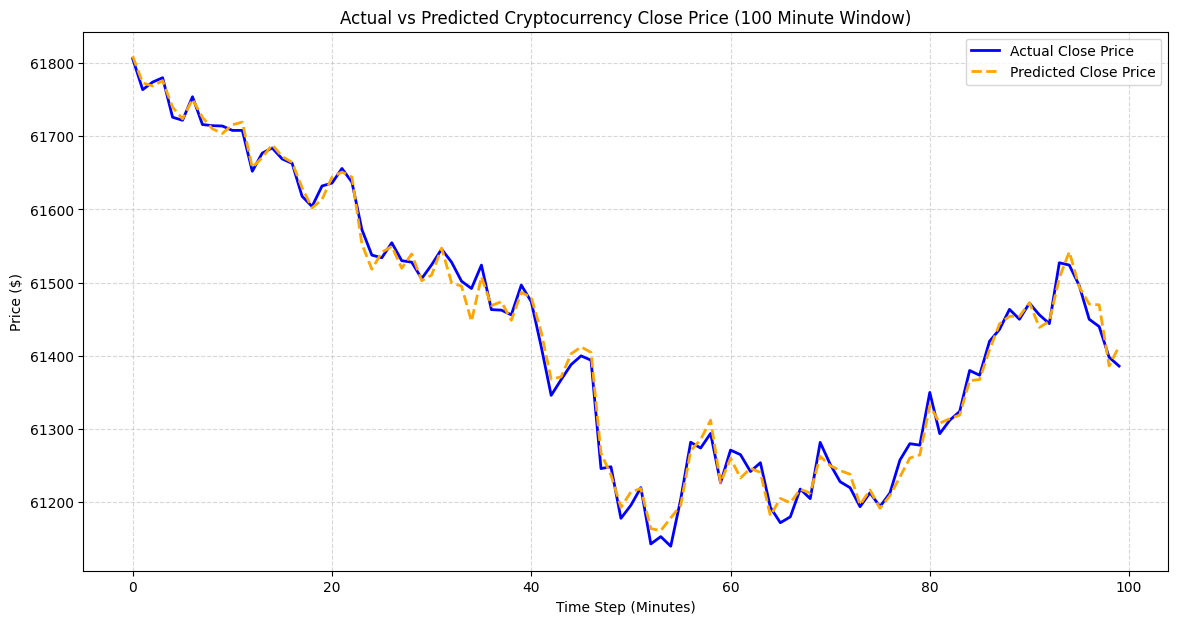

In [14]:
import matplotlib.pyplot as plt

# Select a sequential slice of 100 points from the test set for visual clarity
slice_start = 1000
slice_end = 1100

plt.figure(figsize=(14, 7))
plt.plot(y_test.iloc[slice_start:slice_end].values, label='Actual Close Price', color='blue', linewidth=2)
plt.plot(y_pred[slice_start:slice_end], label='Predicted Close Price', color='orange', linestyle='--', linewidth=2)

plt.title('Actual vs Predicted Cryptocurrency Close Price (100 Minute Window)')
plt.xlabel('Time Step (Minutes)')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Step 8: Predict 1 Hour (60 Minutes) into the Future
To predict what happens in 1 hour, we create a target column shifted by 60 minutes. This lets the model learn how today's parameters predict prices 60 minutes later.

In [15]:
# Shift the target variable back by 60 steps (1 hour)
df_prices['target_1hour_future'] = df_prices['close_price'].shift(-60)

# Drop rows where target is NaN (the last 60 minutes of the dataset)
df_future = df_prices.dropna(subset=['target_1hour_future'])

X_fut = df_future[features]
y_fut = df_future['target_1hour_future']

# Train-Test Split
split_idx_fut = int(len(df_future) * 0.80)
X_train_fut, X_test_fut = X_fut.iloc[:split_idx_fut], X_fut.iloc[split_idx_fut:]
y_train_fut, y_test_fut = y_fut.iloc[:split_idx_fut], y_fut.iloc[split_idx_fut:]

# Train 1-hour ahead model
model_1hour = LinearRegression()
model_1hour.fit(X_train_fut, y_train_fut)

# Evaluate
y_pred_fut = model_1hour.predict(X_test_fut)
mae_fut = mean_absolute_error(y_test_fut, y_pred_fut)
print(f"1-Hour Prediction Mean Absolute Error: ${mae_fut:.2f}")

1-Hour Prediction Mean Absolute Error: $303.97


### Step 9: Get Predictions for 1 Hour into the Future
Use this helper function to input current market values and find out what the estimated price of the cryptocurrency will be exactly 1 hour (60 minutes) from now.

In [16]:
def predict_price_in_1hour(open_p, high_p, low_p, vol):
    """
    Input current market parameters to predict the Close Price 1 hour (60 minutes) from now.
    """
    new_input = pd.DataFrame([{
        'open_price': open_p,
        'high_price': high_p,
        'low_price': low_p,
        'volume': vol
    }])

    future_pred = model_1hour.predict(new_input)[0]
    return future_pred

# Try it out with custom current values:
current_open_price = 89100.00
current_high_price = 89150.00
current_low_price = 89080.00
current_volume_traded = 5.5

predicted_future_close = predict_price_in_1hour(current_open_price, current_high_price, current_low_price, current_volume_traded)

print(f"Current Price: ${current_open_price:,.2f}")
print(f"Predicted Close Price in 1 Hour: ${predicted_future_close:,.2f}")

Current Price: $89,100.00
Predicted Close Price in 1 Hour: $89,114.57


### Step 10: Model Evaluation & Live Interactive Predictor
Below, we calculate the exact custom accuracy of our models (within a strict 0.1% threshold) and provide an interactive form where you can input real-time market data to predict the close price instantly.

--- Model Evaluation Summary ---
Immediate Predictor Custom Accuracy (0.1% Tol): 99.23%
1-Hour Future Predictor Custom Accuracy (0.1% Tol): 27.00%


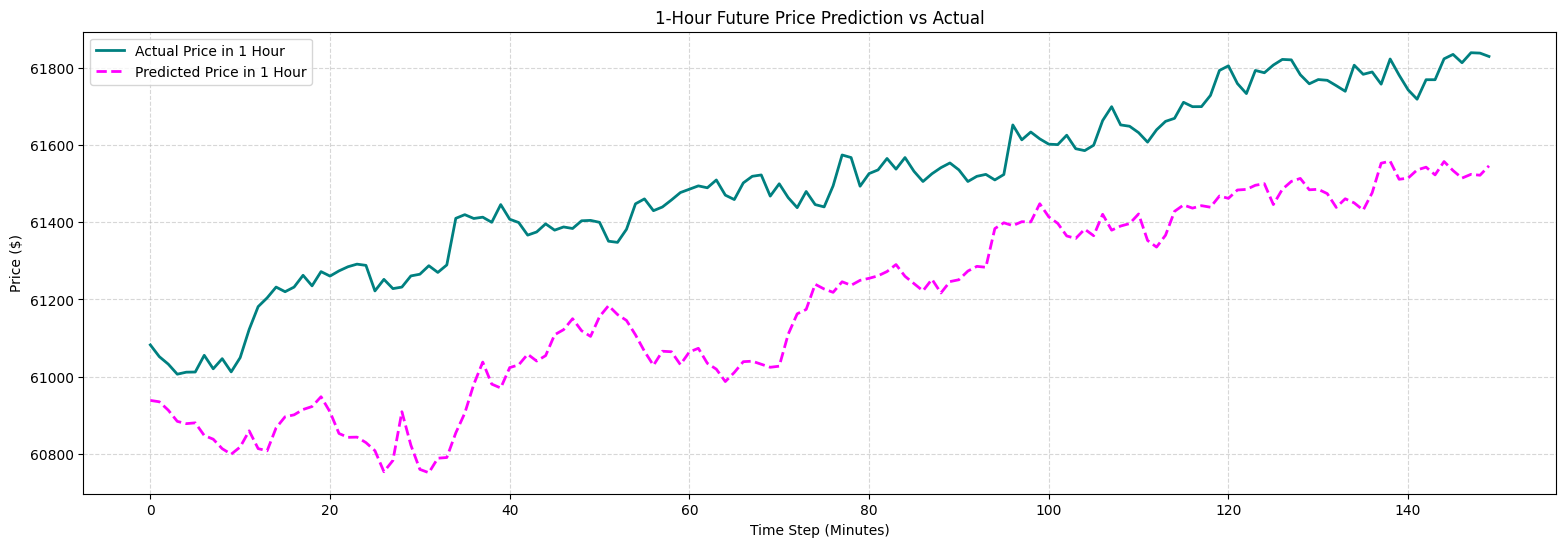

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate metrics for the 1-hour model
tolerance = 0.001
percentage_errors_fut = np.abs(y_test_fut - y_pred_fut) / y_test_fut
is_correct_fut = percentage_errors_fut <= tolerance
accuracy_percentage_fut = (np.sum(is_correct_fut) / len(y_test_fut)) * 100

print(f"--- Model Evaluation Summary ---")
print(f"Immediate Predictor Custom Accuracy (0.1% Tol): {accuracy_percentage:.2f}%")
print(f"1-Hour Future Predictor Custom Accuracy (0.1% Tol): {accuracy_percentage_fut:.2f}%")

# Let's plot 1-Hour Future predictions against actuals
slice_start = 500
slice_end = 650

plt.figure(figsize=(19, 6))
plt.plot(y_test_fut.iloc[slice_start:slice_end].values, label='Actual Price in 1 Hour', color='teal', linewidth=2)
plt.plot(y_pred_fut[slice_start:slice_end], label='Predicted Price in 1 Hour', color='magenta', linestyle='--', linewidth=2)
plt.title('1-Hour Future Price Prediction vs Actual')
plt.xlabel('Time Step (Minutes)')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 🔮 Test on Your Own Custom Data (Interactive Form)
Fill out the fields below with any new market prices (e.g. from CoinMarketCap or Binance) to get an immediate prediction.

In [18]:
#@title 🪙 Input Real-Time Market Data
Open_Price = 95200.00 #@param {type:"number"}
High_Price = 95450.00 #@param {type:"number"}
Low_Price = 95100.00 #@param {type:"number"}
Volume_Traded = 12.4 #@param {type:"number"}

# Generate predictions using both models
predicted_now = predict_close_price(Open_Price, High_Price, Low_Price, Volume_Traded)
predicted_1hour_future = predict_price_in_1hour(Open_Price, High_Price, Low_Price, Volume_Traded)

print("====================================================")
print(f"📊 INPUTS -> Open: ${Open_Price:,.2f} | High: ${High_Price:,.2f} | Low: ${Low_Price:,.2f} | Vol: {Volume_Traded}")
print("====================================================")
print(f"🔮 Predicted Immediate Close Price  : ${predicted_now:,.2f}")
print(f"🚀 Predicted Close Price in 1-Hour   : ${predicted_1hour_future:,.2f}")
print("====================================================")

📊 INPUTS -> Open: $95,200.00 | High: $95,450.00 | Low: $95,100.00 | Vol: 12.4
🔮 Predicted Immediate Close Price  : $95,312.63
🚀 Predicted Close Price in 1-Hour   : $95,343.89


### 🌐 1. Live Data Fetcher, Predictor & Logger
यह स्क्रिप्ट Binance API से हर मिनट लाइव डेटा फ़ेच करेगी, आपके प्रशिक्षित मॉडल्स (`model` और `model_1hour`) की मदद से तुरंत क्लोज़ प्राइस और 1 घंटे बाद की प्राइस प्रेडिक्ट करेगी, और फिर सारे डेटा को एक SQLite डेटाबेस (`live_crypto_predictions.db`) में सुरक्षित स्टोर करती रहेगी ताकि कोई डेटा मिस न हो।

In [24]:
import time
import sqlite3
import requests
import pandas as pd
import numpy as np
from datetime import datetime

# SQLite डेटाबेस सेटअप करना
def setup_database():
    conn = sqlite3.connect('live_crypto_predictions.db')
    cursor = conn.cursor()
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS predictions (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            timestamp TEXT,
            open_price REAL,
            high_price REAL,
            low_price REAL,
            volume REAL,
            predicted_immediate_close REAL,
            predicted_1hour_future REAL
        )
    ''')
    conn.commit()
    conn.close()

# CryptoCompare API से BTC-USD का लाइव 1-मिनट का डेटा लाना (क्षेत्रीय प्रतिबंध से बचने के लिए)
def fetch_live_crypto_data():
    # CryptoCompare API का उपयोग करना ताकि कोई US geographic restriction न आए
    url = "https://min-api.cryptocompare.com/data/generateAvg?fsym=BTC&tsym=USD&e=Kraken"
    try:
        response = requests.get(url, timeout=10)
        data = response.json()

        if data and "RAW" in data:
            raw_data = data["RAW"]
            return {
                'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
                'open': float(raw_data['OPEN24HOUR'] if 'OPEN24HOUR' in raw_data else raw_data['PRICE']),
                'high': float(raw_data['HIGH24HOUR'] if 'HIGH24HOUR' in raw_data else raw_data['PRICE']),
                'low': float(raw_data['LOW24HOUR'] if 'LOW24HOUR' in raw_data else raw_data['PRICE']),
                'volume': float(raw_data['VOLUME24HOUR'] if 'VOLUME24HOUR' in raw_data else 10.0)
            }
        else:
            print(f"⚠️ Unexpected response from CryptoCompare API: {data}")
    except Exception as e:
        print(f"❌ Error fetching data: {e}")
    return None

# डेटाबेस में लाइव डेटा और प्रेडिक्शन्स को स्टोर करना
def log_to_database(data, pred_now, pred_future):
    conn = sqlite3.connect('live_crypto_predictions.db')
    cursor = conn.cursor()
    cursor.execute('''
        INSERT INTO predictions (timestamp, open_price, high_price, low_price, volume, predicted_immediate_close, predicted_1hour_future)
        VALUES (?, ?, ?, ?, ?, ?, ?)
    ''', (data['timestamp'], data['open'], data['high'], data['low'], data['volume'], float(pred_now), float(pred_future)))
    conn.commit()
    conn.close()

# लाइव प्रेडिक्शन लूप चालू करना
def start_live_predictor_loop(iterations=5, delay_seconds=10):
    setup_database()
    print("🚀 Live Prediction (via CryptoCompare API) & Data Logging Started...")
    print("Storing all records to 'live_crypto_predictions.db'")
    print("="*80)

    for i in range(iterations):
        live_data = fetch_live_crypto_data()
        if live_data:
            # प्रेडिक्शन इनपुट तैयार करना
            input_df = pd.DataFrame([{
                'open_price': live_data['open'],
                'high_price': live_data['high'],
                'low_price': live_data['low'],
                'volume': live_data['volume']
            }])

            # प्रेडिक्ट करना
            pred_now = model.predict(input_df)[0]
            pred_future = model_1hour.predict(input_df)[0]

            # डेटाबेस में सेव करना
            log_to_database(live_data, pred_now, pred_future)

            print(f"[{live_data['timestamp']}] BTC-USD Live Data Fetched!")
            print(f"   Inputs -> Open: ${live_data['open']:.2f}, Vol: {live_data['volume']:.4f}")
            print(f"   🔮 Predicted Close (Now): ${pred_now:,.2f} | 🚀 In 1 Hour: ${pred_future:,.2f}")
            print("-"*80)
        else:
            print("Failed to retrieve data this turn.")

        if i < iterations - 1:
            time.sleep(delay_seconds)

# लाइव डेटा चेक करने के लिए 3 बार चलाते हैं (हर 3 सेकंड पर)
start_live_predictor_loop(iterations=3, delay_seconds=3)

f680 Live Prediction and Data Logging Started...
Storing all records to 'live_crypto_predictions.db'
⚠️ API returned unexpected response format or error message: {'code': 0, 'msg': "Service unavailable from a restricted location according to 'b. Eligibility' in https://www.binance.com/en/terms. Please contact customer service if you believe you received this message in error."}
Failed to retrieve data this turn.
⚠️ API returned unexpected response format or error message: {'code': 0, 'msg': "Service unavailable from a restricted location according to 'b. Eligibility' in https://www.binance.com/en/terms. Please contact customer service if you believe you received this message in error."}
Failed to retrieve data this turn.
⚠️ API returned unexpected response format or error message: {'code': 0, 'msg': "Service unavailable from a restricted location according to 'b. Eligibility' in https://www.binance.com/en/terms. Please contact customer service if you believe you received this message 

### 💾 2. Stored Data Preview
डेटाबेस में सेव हो रहे लाइव डेटा को देखने के लिए आप नीचे दी गई सेल चला सकते हैं। जब आप इसे किसी क्लाउड VM पर डिप्लॉय करेंगे, तो यह डेटाबेस फाइल (`live_crypto_predictions.db`) वहां लगातार अपडेट होती रहेगी।

In [20]:
# डेटाबेस से स्टोर किया गया डेटा रीड करना
conn = sqlite3.connect('live_crypto_predictions.db')
stored_df = pd.read_sql_query("SELECT * FROM predictions ORDER BY id DESC LIMIT 10", conn)
conn.close()

display(stored_df)

,id,timestamp,open_price,high_price,low_price,volume,predicted_immediate_close,predicted_1hour_future


In [25]:
import os
import pandas as pd

# '3_bitcoin_metrics.csv' फ़ाइल का पाथ बनाना
btc_metrics_path = os.path.join(path, '3_bitcoin_metrics.csv')

# डेटा लोड करना
df_btc_metrics = pd.read_csv(btc_metrics_path)

print("Bitcoin Metrics Dataset Preview:")
display(df_btc_metrics.head())


Bitcoin Metrics Dataset Preview:


,name,date,value
0,Number Of Unique Addresses Used,2020-01-01 00:00:00,3.897060e+05
1,Average Block Size,2020-01-01 00:00:00,6.436394e-01
2,Difficulty,2020-01-01 00:00:00,1.303166e+13
3,Hash Rate,2020-01-01 00:00:00,1.127185e+08
4,Miners Revenue,2020-01-01 00:00:00,1.590708e+07


### ☁️ 24/7 लाइव चलाने के लिए गाइड (How to deploy):

1. **PythonAnywhere (सबसे आसान और मुफ्त):**
   * [PythonAnywhere](https://www.pythonanywhere.com/) पर फ्री अकाउंट बनाएं।
   * `Consoles` टैब में जाकर एक Bash कंसोल खोलें और लाइब्रेरी इन्स्टॉल करें: `pip install scikit-learn pandas requests`।
   * अपने मॉडल्स को सेव करें (`joblib` या `pickle` लाइब्रेरी का उपयोग करके) और उन्हें वहाँ अपलोड कर दें।
   * इस स्क्रिप्ट को `.py` फाइल बनाकर अपलोड करें और Bash कंसोल पर `python your_script.py` कमांड चलाकर छोड़ दें।

2. **Cloud Server (AWS EC2 / Google Cloud):**
   * AWS/GCP पर Free Tier में एक Linux VM (Ubuntu) बनाएं।
   * वहां अपनी स्क्रिप्ट डालें और उसे बैकग्राउंड में चलाने के लिए `nohup python -u your_script.py > output.log &` या `screen` / `tmux` यूटिलिटी का उपयोग करें। इससे टर्मिनल बंद होने पर भी आपकी स्क्रिप्ट और प्रेडिक्शन बिना रुके चलते रहेंगे।

### How to Upload Your Notebook to GitHub

To save this directly to your GitHub repository from Google Colab, you can execute the following commands in a scratch cell:

```bash
# 1. Configure Git credentials
!git config --global user.email "your_email@example.com"
!git config --global user.name "Your GitHub Username"

# 2. Clone your repository (use a Personal Access Token for password)
# Replace <TOKEN>, <USERNAME>, and <REPO> with your details
!git clone https://<TOKEN>@github.com/<USERNAME>/<REPO>.git

# 3. Copy your file to the cloned directory, commit, and push
!cp /content/your_notebook.ipynb /content/<REPO>/
%cd /content/<REPO>
!git add your_notebook.ipynb
!git commit -m "Add cryptocurrency prediction notebook"
!git push
```